In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths to the dataset
train_dir = 'caltech101_train'
val_dir = 'caltech101_val'

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 7280 images belonging to 102 classes.
Found 1864 images belonging to 102 classes.


In [2]:
from keras.models import Sequential, Model
from keras.layers import Conv2D, Input, Dropout, Activation, Dense, MaxPooling2D, Flatten, GlobalAveragePooling2D
from keras.optimizers import Adadelta
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from keras.models import load_model
from keras.applications.inception_v3 import InceptionV3

In [3]:
from loglu import LogLU

In [8]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(1024, activation='relu')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='relu')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(102, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [9]:
history_relu=transfer_learning_model.fit(train_generator, batch_size=32, epochs=30, verbose=1, validation_data=val_generator)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.0531 - loss: 4.6564 - val_accuracy: 0.2334 - val_loss: 3.6192
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.2119 - loss: 3.7645 - val_accuracy: 0.2881 - val_loss: 3.2543
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.2763 - loss: 3.4005 - val_accuracy: 0.3450 - val_loss: 3.0537
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.3230 - loss: 3.2191 - val_accuracy: 0.4029 - val_loss: 2.8539
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.3700 - loss: 3.0482 - val_accuracy: 0.4388 - val_loss: 2.6238
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.3964 - loss: 2.8872 - val_accuracy: 0.4726 - val_loss: 2.4300
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.4213 - loss: 2.7203 - val_accuracy: 0.5113 - val_loss: 2.2374
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.4673 - loss: 2.5409 - val_accu

In [10]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(1024, activation=tf.keras.activations.leaky_relu)(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation=tf.keras.activations.leaky_relu)(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(102, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [11]:
history_leaky=transfer_learning_model.fit(train_generator, batch_size=32, epochs=30, verbose=1, validation_data=val_generator)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.0736 - loss: 4.4681 - val_accuracy: 0.2452 - val_loss: 3.4753
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.2451 - loss: 3.6077 - val_accuracy: 0.3273 - val_loss: 3.1071
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.3137 - loss: 3.2993 - val_accuracy: 0.3788 - val_loss: 2.8306
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.3704 - loss: 2.9969 - val_accuracy: 0.4238 - val_loss: 2.5909
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 387s 2s/step - accuracy: 0.3988 - loss: 2.8320 - val_accuracy: 0.4887 - val_loss: 2.3430
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.4280 - loss: 2.7013 - val_accuracy: 0.5531 - val_loss: 2.1041
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.4820 - loss: 2.4329 - val_accuracy: 0.6170 - val_loss: 1.8351
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.5362 - loss: 2.2133 - val_accu

In [12]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(1024, activation='elu')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='elu')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(102, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [13]:
history_elu=transfer_learning_model.fit(train_generator, batch_size=32, epochs=30, verbose=1, validation_data=val_generator)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 391s 2s/step - accuracy: 0.0903 - loss: 4.5747 - val_accuracy: 0.3063 - val_loss: 3.2114
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.2818 - loss: 3.4543 - val_accuracy: 0.4147 - val_loss: 2.7166
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.3626 - loss: 3.0642 - val_accuracy: 0.5161 - val_loss: 2.3047
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.4475 - loss: 2.6502 - val_accuracy: 0.5907 - val_loss: 1.9374
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.4958 - loss: 2.3712 - val_accuracy: 0.6508 - val_loss: 1.6375
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.5506 - loss: 2.0498 - val_accuracy: 0.6985 - val_loss: 1.3810
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.6093 - loss: 1.7754 - val_accuracy: 0.7430 - val_loss: 1.1784
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.6482 - loss: 1.6046 - val_accu

In [14]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(1024, activation='swish')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='swish')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(102, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [15]:
history_swish=transfer_learning_model.fit(train_generator, batch_size=32, epochs=30, verbose=1, validation_data=val_generator)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.0747 - loss: 4.4835 - val_accuracy: 0.2629 - val_loss: 3.4392
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.2481 - loss: 3.5534 - val_accuracy: 0.3181 - val_loss: 3.1521
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.3073 - loss: 3.2550 - val_accuracy: 0.3616 - val_loss: 2.9412
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.3485 - loss: 3.1234 - val_accuracy: 0.4227 - val_loss: 2.7096
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.4014 - loss: 2.9294 - val_accuracy: 0.4683 - val_loss: 2.4427
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.4407 - loss: 2.6873 - val_accuracy: 0.5279 - val_loss: 2.1889
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.4769 - loss: 2.4777 - val_accuracy: 0.5842 - val_loss: 1.9450
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.5189 - loss: 2.2762 - val_accu

In [16]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(1024, activation='mish')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='mish')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(102, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [17]:
history_mish=transfer_learning_model.fit(train_generator, batch_size=32, epochs=30, verbose=1, validation_data=val_generator)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.0762 - loss: 4.4960 - val_accuracy: 0.2575 - val_loss: 3.3736
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.2642 - loss: 3.5328 - val_accuracy: 0.3482 - val_loss: 3.0339
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.3240 - loss: 3.2275 - val_accuracy: 0.4072 - val_loss: 2.7613
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.3824 - loss: 2.9331 - val_accuracy: 0.4828 - val_loss: 2.4663
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.4300 - loss: 2.7389 - val_accuracy: 0.5300 - val_loss: 2.1662
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.4753 - loss: 2.5085 - val_accuracy: 0.5869 - val_loss: 1.9153
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.5147 - loss: 2.2603 - val_accuracy: 0.6357 - val_loss: 1.6924
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.5609 - loss: 2.0328 - val_accu

In [19]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(1024, activation=LogLU())(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation=LogLU())(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(102, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)

In [20]:
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [21]:
history=transfer_learning_model.fit(train_generator, batch_size=32, epochs=30, verbose=1, validation_data=val_generator)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.0827 - loss: 4.5712 - val_accuracy: 0.2806 - val_loss: 3.2311
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.2728 - loss: 3.4829 - val_accuracy: 0.4136 - val_loss: 2.7390
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.3728 - loss: 2.9975 - val_accuracy: 0.5005 - val_loss: 2.3299
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.4391 - loss: 2.6606 - val_accuracy: 0.5746 - val_loss: 1.9947
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.4916 - loss: 2.3742 - val_accuracy: 0.6389 - val_loss: 1.6881
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.5529 - loss: 2.0973 - val_accuracy: 0.6931 - val_loss: 1.4235
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.5983 - loss: 1.8316 - val_accuracy: 0.7414 - val_loss: 1.1910
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.6524 - loss: 1.5936 - val_accu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

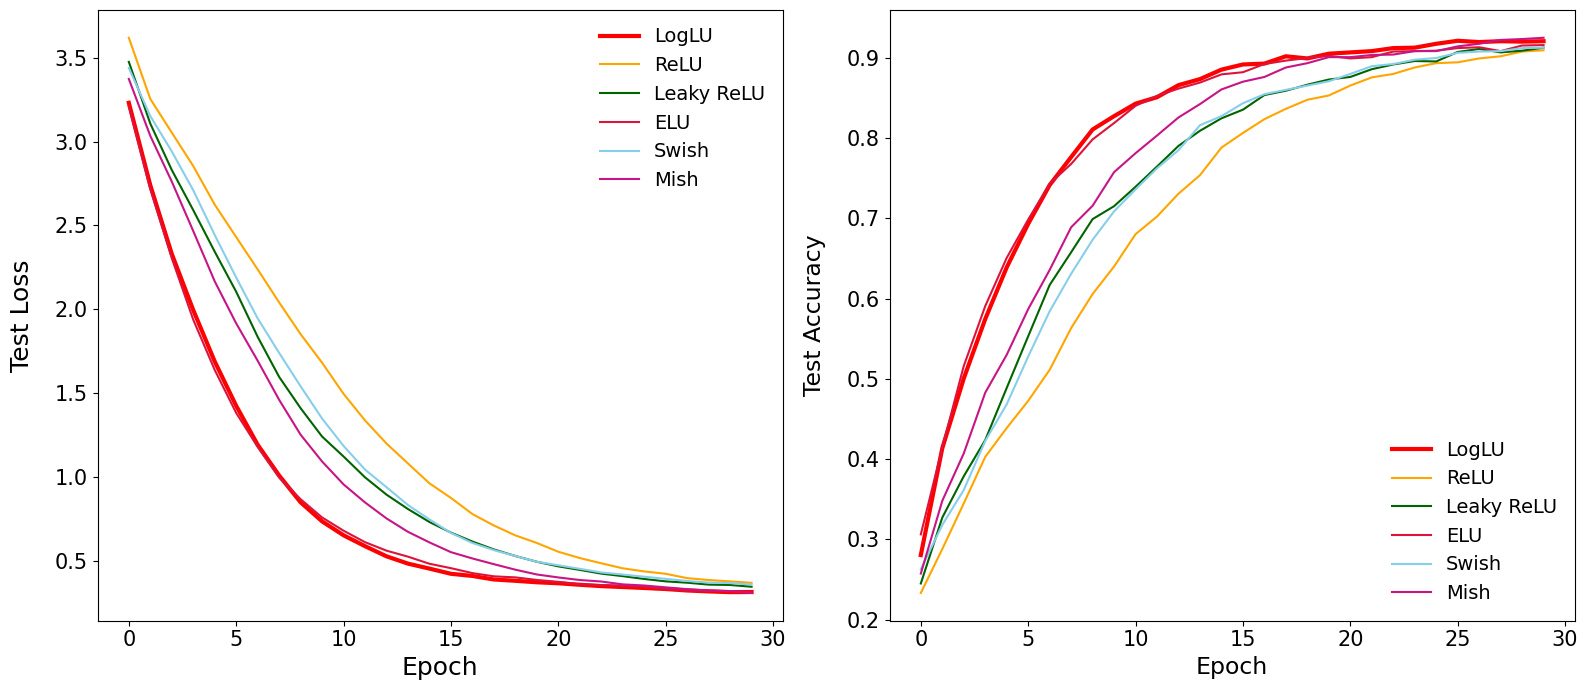

In [22]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='LogLU', color='red', linewidth=3)
plt.plot(history_relu.history['val_loss'],label='ReLU', color='orange')
plt.plot(history_leaky.history['val_loss'],label='Leaky ReLU', color='darkgreen')
plt.plot(history_elu.history['val_loss'], label='ELU', color='crimson')
plt.plot(history_swish.history['val_loss'], label='Swish', color='skyblue')
plt.plot(history_mish.history['val_loss'], label='Mish', color='mediumvioletred')
plt.ylabel('Test Loss', fontsize=18, labelpad=15)
plt.xlabel('Epoch', fontsize=18)
plt.legend(fontsize=14,loc='upper right',frameon=False)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)


plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='LogLU', color='red', linewidth=3)
plt.plot(history_relu.history['val_accuracy'],label='ReLU', color='orange')
plt.plot(history_leaky.history['val_accuracy'],label='Leaky ReLU', color='darkgreen')
plt.plot(history_elu.history['val_accuracy'], label='ELU', color='crimson')
plt.plot(history_swish.history['val_accuracy'], label='Swish', color='skyblue')
plt.plot(history_mish.history['val_accuracy'], label='Mish', color='mediumvioletred')
plt.ylabel('Test Accuracy', fontsize=17, labelpad=15)
plt.xlabel('Epoch', fontsize=17)
plt.legend(fontsize=14,loc='lower right',frameon=False)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()

plt.savefig('Caltech 101_Final.png', dpi=500)
plt.show()

In [23]:
transfer_learning_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, None, None, 3)     │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_564 (Conv2D)           │ (None, None, None, 32)    │             864 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_564       │ (None, None, None, 32)    │              96 │ conv2d_564[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_564 (Activation)   │ (None, None, None, 32)    │               0 │ batch_normalization_564[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_565 (Conv2D)           │ (None, None, None, 32)    │           9,216 │ activation_564[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_565       │ (None, None, None, 32)    │              96 │ conv2d_565[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_565 (Activation)   │ (None, None, None, 32)    │               0 │ batch_normalization_565[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_566 (Conv2D)           │ (None, None, None, 64)    │          18,432 │ activation_565[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_566       │ (None, None, None, 64)    │             192 │ conv2d_566[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_566 (Activation)   │ (None, None, None, 64)    │               0 │ batch_normalization_566[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_24              │ (None, None, None, 64)    │               0 │ activation_566[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_567 (Conv2D)           │ (None, None, None, 80)    │           5,120 │ max_pooling2d_24[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_567       │ (None, None, None, 80)    │             240 │ conv2d_567[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_567 (Activation)   │ (None, None, None, 80)    │               0 │ batch_normalization_567[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_568 (Conv2D)           │ (None, None, None, 192)   │         138,24

 Total params: 73,365,396 (279.87 MB)

 Trainable params: 24,443,654 (93.25 MB)

 Non-trainable params: 34,432 (134.50 KB)

 Optimizer params: 48,887,310 (186.49 MB)